# Customer Churn Prediction
## Predicting customer churn using Logistic Regression

In this project, I build a Logistic Regression model to predict whether a customer will churn (Churned), using the same online retail customer dataset as our Total Spend prediction project — this time framed as a binary classification problem rather than a regression problem.


#### Load the dependencies
First, I need to load the necessary libraries. This includes:
* The pandas library, which is used for data manipulation and analysis.
* The train_test_split function to split the data into training and testing sets.
* The LogisticRegression class, which is a linear model for binary classification
* The accuracy_score function which is used to measure the performance of a classifier model.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn import preprocessing
import matplotlib.pyplot as plt

#### Load the data
First, download the dataset from Moodle as a CSV file called data_online_retail_customers.csv. Once downloaded, upload the csv file on your Colab notebook.

Let's load the dataset from the csv file provided as follows:

In [3]:
# Load the data
data = pd.read_csv("data_online_retail_customers.csv")

> **Explanation of the code:** data = pd.read_csv("data_online_retail_customers.csv") reads the data from 'data_online_retail_customers.csv' file and loads into data variable using the read_csv function from the pandas library (aliased as pd).


I can have a quick look at the data type of all variables in the dataset as follows:

In [4]:
# Print the data type of all variables
print(data.dtypes)

Customer_ID                  int64
Age                          int64
Gender                      object
Annual_Income              float64
Total_Spend                float64
Years_as_Customer            int64
Num_of_Purchases             int64
Num_of_Returns               int64
Num_of_Support_Contacts      int64
Satisfaction_Score           int64
Last_Purchase_Days_Ago       int64
Email_Opt_In                  bool
Promotion_Response          object
Churned                       bool
dtype: object


Notice that Gender and Promotion_Response are of type object and would need to be transformed into categorical variables.

#### Data transformation
I would first need to convert plain text data (shown as type object) into numeric or categorical data. e.g. Gender and Promotion_Response should be categorical. I do that as follows:

In [5]:
# Convert categorical columns to 'category' dtype
data['Gender'] = data['Gender'].astype('category')
data['Promotion_Response'] = data['Promotion_Response'].astype('category')

Now that text data is transformed into categorical data, I can have a look at the data type of all variables in the dataset to check that the tranformation has been applied. I notice that Gender and Promotion_Response are now categorical variables.

In [6]:
# Print the data type of all variables
print(data.dtypes)

Customer_ID                   int64
Age                           int64
Gender                     category
Annual_Income               float64
Total_Spend                 float64
Years_as_Customer             int64
Num_of_Purchases              int64
Num_of_Returns                int64
Num_of_Support_Contacts       int64
Satisfaction_Score            int64
Last_Purchase_Days_Ago        int64
Email_Opt_In                   bool
Promotion_Response         category
Churned                        bool
dtype: object


I would also need to convert categorical variables to dummy/indicator variables for use in the logistic regression late.

In [7]:
# Convert categorical variables to dummy/indicator variables
data = pd.get_dummies(data, drop_first=True)

Now that categorical data is transformed into dummy/indicator variables, I can have a look at the data type of all variables in the dataset to check that the tranformation has been applied.

In [8]:
# Print the data type of all variables
print(data.dtypes)

Customer_ID                          int64
Age                                  int64
Annual_Income                      float64
Total_Spend                        float64
Years_as_Customer                    int64
Num_of_Purchases                     int64
Num_of_Returns                       int64
Num_of_Support_Contacts              int64
Satisfaction_Score                   int64
Last_Purchase_Days_Ago               int64
Email_Opt_In                          bool
Churned                               bool
Gender_Male                           bool
Promotion_Response_Responded          bool
Promotion_Response_Unsubscribed       bool
dtype: object


#### Feature Selection and Splitting the data into inputs (X) and outputs (y) to predict customer churn

I would also have to select the variables that could be factors influencing customer churn. In this case, Customer_ID is clearly an ID and cannot be a predictor of customer churn. All other variables can be considered as inputs.

Now, let's split the data into input (X) and output (y) variables as follows:

In [9]:
# Split the data into inputs (X) and outputs (y)
X = data.drop(columns=['Customer_ID', 'Churned'])
y = data["Churned"]

#### Preprocess the data (scaling)
Scale the numeric input data to ensure that all the input features are on the same scale. It standardizes the data by subtracting the mean and dividing by the standard deviation.

In [10]:
# Scale the numeric input data
# Identify numeric columns
numeric_columns = X.select_dtypes(include=['float64', 'int64']).columns

# Scale numeric columns
scaler = preprocessing.StandardScaler().fit(X[numeric_columns])
X[numeric_columns] = scaler.transform(X[numeric_columns])

#### Split the data into training and testing sets
Split the data into training and testing sets. The training set will be used to train the model, while the testing set will be used to test the accuracy of the model.

In [11]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

> **Explanation of the code:** Split the input and output data using the train_test_split function into training and testing set with test_size =0.2 meaning that the testing set corresponds to 20% of the data.

#### Train a logistic regression model on the training data
Let's Create a logistic regression model and train it using the training dataset

In [12]:
# Train a logistic regression model on the training data
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

> **Explanation of the code:** model = LogisticRegression() creates an instance of the LogisticRegression model.

> model.fit(X_train, y_train) trains the logistic regression model using the training data.


#### Make predictions on the testing data

In [13]:
# Make predictions on the testing data
y_pred = model.predict(X_test)

> **Explanation of the code:** model.predict function is used to predict the outcome of the testing data (X_test).

### Calculate the accuracy of the model

Calculate the accuracy of the model by comparing the predictions with the true values in y_test

In [14]:
# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.47794117647058826


> **Explanation of the code:** accuracy = accuracy_score(y_test, y_pred) calculates the accuracy of the model. print allows to display the calculated accuracy.

#### Precision, Recall and F1 Score to assess the performance of the model in making predictions

While accuracy is a relevant metric, it is not comprehensive to assess the performance of the model. The metrics Precision, Recall, and F1 score provide more insights into the model's performance. Each of these metrics provides different insights into the model's performance, particularly in terms of how Ill the model is identifying the relevant instances (cases) of customer churn.


In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score
# Calculate precision, recall, and F1 score
precision = precision_score(y_test, y_pred, average='macro')  # or 'micro', 'weighted' depending on your need
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Precision: 0.4732142857142857
Recall: 0.4739978331527628
F1 Score: 0.4715122324995895


#### Generate the results of the logistic regression model

In this step I generate the coefficients of features to figure out which features in our data are most important for our machine learning model. This code will display the coefficients of the features used in the logistic regression model to predict whether a customer will churn based on various factors such as age, annual income, total spend, and more. I want to see which features had the most influence on the predictions.

Display feature coefficients


In [16]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})
print(coefficients)

                            Feature  Coefficient
0                               Age    -0.034270
1                     Annual_Income     0.071693
2                       Total_Spend     0.065094
3                 Years_as_Customer     0.113789
4                  Num_of_Purchases    -0.098093
5                    Num_of_Returns     0.063994
6           Num_of_Support_Contacts    -0.137789
7                Satisfaction_Score     0.062604
8            Last_Purchase_Days_Ago     0.004642
9                      Email_Opt_In    -0.252588
10                      Gender_Male     0.001672
11     Promotion_Response_Responded     0.097336
12  Promotion_Response_Unsubscribed    -0.029028


**Interpreting the results**

**Accuracy: 0.478** — this is below our 51.5% majority-class benchmark. In other words, the model performs worse than simply guessing "not churned" for every customer.

**Precision: 0.473, Recall: 0.474, F1 Score: 0.472** — all close to 0.5, which is what I'd expect from a model that isn't picking up any real signal in a roughly balanced dataset. These numbers confirm the accuracy result isn't a fluke: the model isn't distinguishing churned from non-churned customers in any meaningful way.

This mirrors what I found in our Total Spend regression project on the same dataset — individual features shoId almost no correlation with the target there either. It's consistent with this being a dataset generated for practice purposes, where the outcome variables (Total_Spend, Churned) Iren't deliberately built to depend on the other columns.

**Feature coefficients** — given how Iak the model's overall performance is, I treat these as exploratory rather than reliable drivers of churn. The largest-magnitude coefficients are Email_Opt_In (-0.253), Num_of_Support_Contacts (-0.138), Years_as_Customer (+0.114), Num_of_Purchases (-0.098), and Promotion_Response_Responded (+0.097) — but with accuracy below a naive baseline, I wouldn't act on these patterns without first establishing that the model has genuine predictive poIr.

**Next steps:** since the issue appears to be limited signal in the dataset rather than a modelling choice, a next step would be to test whether non-linear models (e.g. Random Forest, Gradient Boosting) can extract any pattern a linear decision boundary can't, or to revisit feature engineering and explore additional data sources.

# **Comparing Additional Models**

Since our Logistic Regression model performed below a naive baseline, we want to check whether the limitation is due to the model choice or the data itself. We train three additional classifiers — Random Forest, Gradient Boosting, and Support Vector Machine (SVM) — on the same training/testing split, and compare all four models side by side.


We import the additional model classes we'll need below.

In [17]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# **Random Forest**

Random Forest builds many decision trees on random subsets of the data and features, then averages their predictions. Unlike logistic regression, it can capture non-linear relationships and feature interactions, so it's a good first check on whether non-linearity is the issue.

We train a Random Forest classifier on the same training data.

In [18]:
# Train a Random Forest model on the training data
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

We use the trained model to predict churn on the testing data, then evaluate it with the same metrics as before.

In [19]:
# Make predictions and evaluate the Random Forest model
rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, average='macro')
rf_recall = recall_score(y_test, rf_pred, average='macro')
rf_f1 = f1_score(y_test, rf_pred, average='macro')

print(f"Random Forest — Accuracy: {rf_accuracy}")
print(f"Random Forest — Precision: {rf_precision}")
print(f"Random Forest — Recall: {rf_recall}")
print(f"Random Forest — F1 Score: {rf_f1}")

Random Forest — Accuracy: 0.47794117647058826
Random Forest — Precision: 0.47857142857142854
Random Forest — Recall: 0.4785482123510293
Random Forest — F1 Score: 0.4779129494457962


# **Gradient Boosting**

Gradient Boosting builds trees sequentially, with each new tree correcting the errors of the previous ones. It's generally one of the strongest performers among tree-based models, so if any model can find signal in this dataset, this is a good candidate.

We train a Gradient Boosting classifier on the same training data.

In [20]:
# Train a Gradient Boosting model on the training data
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

We use the trained model to predict churn on the testing data, then evaluate it with the same metrics.

In [21]:
# Make predictions and evaluate the Gradient Boosting model
gb_pred = gb_model.predict(X_test)

gb_accuracy = accuracy_score(y_test, gb_pred)
gb_precision = precision_score(y_test, gb_pred, average='macro')
gb_recall = recall_score(y_test, gb_pred, average='macro')
gb_f1 = f1_score(y_test, gb_pred, average='macro')

print(f"Gradient Boosting — Accuracy: {gb_accuracy}")
print(f"Gradient Boosting — Precision: {gb_precision}")
print(f"Gradient Boosting — Recall: {gb_recall}")
print(f"Gradient Boosting — F1 Score: {gb_f1}")

Gradient Boosting — Accuracy: 0.5
Gradient Boosting — Precision: 0.499675535366645
Gradient Boosting — Recall: 0.49967497291440954
Gradient Boosting — F1 Score: 0.49956709956709955


# **Support Vector Machine (SVM)**

SVM finds the boundary that best separates the two classes, and can model non-linear boundaries using kernel functions. We use it here as a third, quite different approach for comparison.

We train an SVM classifier on the same training data.

In [22]:
# Train a Support Vector Machine model on the training data
svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)

SVC(random_state=42)

We use the trained model to predict churn on the testing data, then evaluate it with the same metrics.

In [23]:
# Make predictions and evaluate the SVM model
svm_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred, average='macro')
svm_recall = recall_score(y_test, svm_pred, average='macro')
svm_f1 = f1_score(y_test, svm_pred, average='macro')

print(f"SVM — Accuracy: {svm_accuracy}")
print(f"SVM — Precision: {svm_precision}")
print(f"SVM — Recall: {svm_recall}")
print(f"SVM — F1 Score: {svm_f1}")

SVM — Accuracy: 0.47058823529411764
SVM — Precision: 0.4650953984287317
SVM — Recall: 0.46630552546045506
SVM — F1 Score: 0.4631578947368421


# **Comparing all four models**

Finally, we bring together the results from Logistic Regression, Random Forest, Gradient Boosting, and SVM into a single table so we can compare their performance directly.

In [24]:
# Build a comparison table of all four models
comparison = pd.DataFrame({
    'Logistic Regression': [accuracy, precision, recall, f1],
    'Random Forest': [rf_accuracy, rf_precision, rf_recall, rf_f1],
    'Gradient Boosting': [gb_accuracy, gb_precision, gb_recall, gb_f1],
    'SVM': [svm_accuracy, svm_precision, svm_recall, svm_f1]
}, index=['Accuracy', 'Precision', 'Recall', 'F1 Score']).T

print(comparison)

                     Accuracy  Precision    Recall  F1 Score
Logistic Regression  0.477941   0.473214  0.473998  0.471512
Random Forest        0.477941   0.478571  0.478548  0.477913
Gradient Boosting    0.500000   0.499676  0.499675  0.499567
SVM                  0.470588   0.465095  0.466306  0.463158


We also plot the accuracy of each model against our majority-class baseline (~51.5%) to visualise how each one compares.

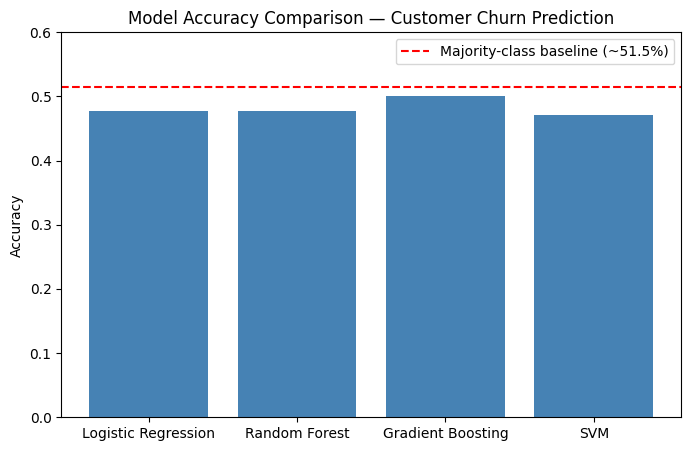

In [25]:
# Plot accuracy of each model against the majority-class baseline
plt.figure(figsize=(8,5))
plt.bar(comparison.index, comparison['Accuracy'], color='steelblue')
plt.axhline(y=0.515, color='red', linestyle='--', label='Majority-class baseline (~51.5%)')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison — Customer Churn Prediction')
plt.legend()
plt.ylim(0, 0.6)
plt.show()

# **Interpreting the comparison**

Across all four models, accuracy sits in a narrow band around 0.47–0.50 — none of them clear the majority-class baseline (51.5%) by a meaningful margin, and Logistic Regression and SVM actually fall below it. Gradient Boosting comes closest to the baseline (0.50), while Random Forest lands close to Logistic Regression.

Precision, Recall, and F1 Score tell the same story for every model: all sit close to 0.47–0.50, which is what we'd expect from models that aren't extracting any real signal from a roughly balanced target, rather than models with a genuine but modest fit.

This is a meaningful result in itself: it isn't that Logistic Regression was the wrong choice — non-linear models with far greater capacity to model complex relationships (Random Forest, Gradient Boosting) and a fundamentally different approach (SVM) all hit the same ceiling. This strengthens our earlier conclusion from the correlation analysis: the limitation lies in the dataset itself, not in the choice of algorithm. If this were a real business dataset, the next step would be to revisit the available features and data collection process, rather than continuing to test more complex models on the same inputs.